In [ ]:
import pandas as pd

In [ ]:
sheet_name = 'Crashpad'
sheet_id = '1EU2bvDxHII2OXUBlZcERz8pgIHKSUUUbWjkCcRInvA4'
gid = '752764722'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}/export?format=csv&gid={gid}"

data = pd.read_csv(url)

data.rename(columns={"quantité PFAS": "quantité PFAS (in µg/L)"},inplace=True)

data = data.replace(to_replace=' µg/L', value='', regex=True)

data['quantité PFAS (in µg/L)'] = data['quantité PFAS (in µg/L)'].astype(float)
data['code'] = data['code'].astype(str)

data.dtypes


#data

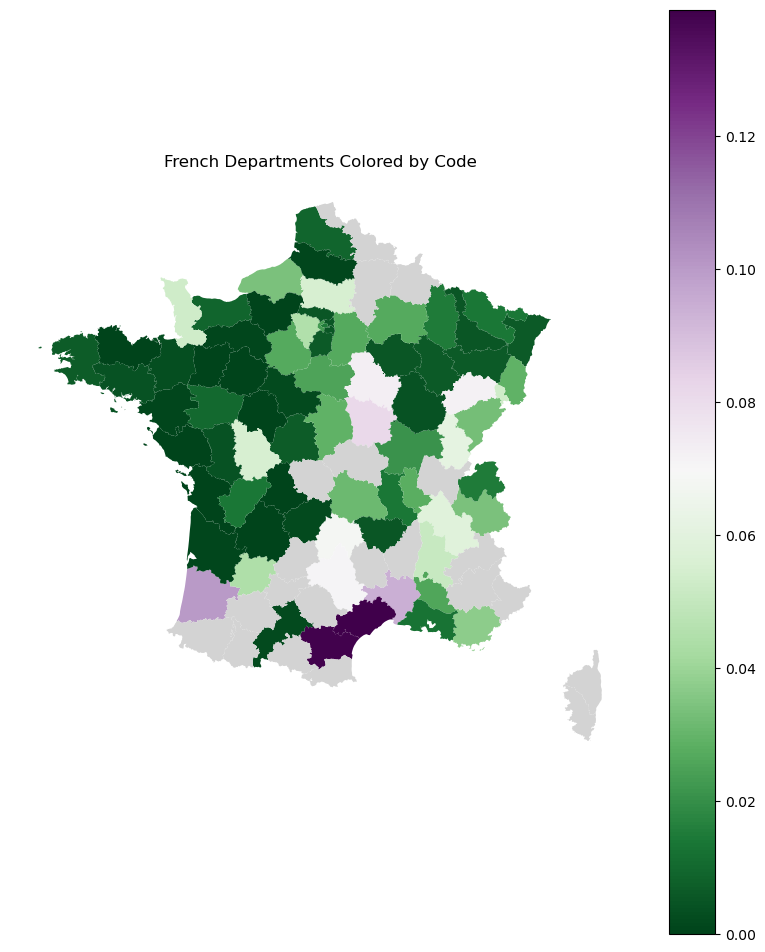

,code,nom,geometry,quantité PFAS (in µg/L),communes testées
0,02,Aisne,"POLYGON ((3.1727 50.012, 3.1822 50.01234, 3.21...",NaN,NaN
1,10,Aube,"POLYGON ((3.41479 48.39027, 3.42208 48.41334, ...",0.005,265 / 431
2,14,Calvados,"POLYGON ((-1.11962 49.35557, -1.11503 49.3624,...",0.009,447 / 557
3,15,Cantal,"POLYGON ((2.50841 45.4785, 2.52444 45.4807, 2....",0.068,34 / 250
4,28,Eure-et-Loir,"POLYGON ((0.81482 48.67016, 0.82767 48.68072, ...",0.027,249 / 375
...,...,...,...,...,...
91,41,Loir-et-Cher,"POLYGON ((0.84122 48.10306, 0.87588 48.10943, ...",0.002,160 / 278
92,53,Mayenne,"POLYGON ((-0.86036 48.50146, -0.84611 48.49828...",0.000,199 / 249
93,54,Meurthe-et-Moselle,"MULTIPOLYGON (((5.45556 49.48093, 5.44953 49.4...",0.005,395 / 594
94,79,Deux-Sèvres,"POLYGON ((-0.89196 46.97582, -0.87973 46.9758,...",0.004,124 / 258


In [50]:
#!pip install geopandas matplotlib

import geopandas as gpd
import matplotlib.pyplot as plt

# Load French departments from the official geojson
url = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
departments = gpd.read_file(url)

departments = departments.merge(data, on='code', how='left')
departments[departments['Region'].isna()] #check null

departments.drop(columns = ['Region'], inplace=True)

# Example: Color by department code
departments.plot(column='quantité PFAS (in µg/L)', cmap='PRGn_r', figsize=(10, 12), legend=True, missing_kwds={
        'color': 'lightgrey',        # Fill color for NaNs
        'label': 'No Data'           # Shown in legend
    })
plt.title("French Departments Colored by Code")
plt.axis('off')
plt.show()

departments
